Checkpoint 4 completed, but it gives us an important warning rather than a “robustness confirmed” result.

The baseline \(10^{-2}\) result is internally reproduced: \(A=1166.08,\ c=1.3538\). But the exponent changes substantially when the absolute threshold changes: \(c=1.2407\) at \(2\times10^{-2}\), \(1.5475\) at \(5\times10^{-3}\), and then the fit becomes poorly identified as the threshold is lowered because many configurations never cross. At \(10^{-3}\), only 5/21 training configurations are usable; at \(10^{-4}\), none are usable. At the high-threshold end, \(10^{-1}\) collapses essentially everything to the first depth and gives \(c\approx0\).

So do not claim that the formula is invariant to threshold choice. The correct conclusion from Checkpoint 4 is: there is a meaningful intermediate threshold regime, but the empirical exponent is sensitive to the absolute threshold outside that regime. That is actually a useful result for the paper because it motivates the next diagnostic.

The monotonicity check is clean: 0 violations across all configurations. So lowering the threshold consistently delays the extracted onset; there is no pathological non-monotonic behavior.

Checkpoint 4 verdict

PASS as a sensitivity analysis.
FAIL if interpreted as proof of threshold invariance.

That distinction is important.

Now we test the deeper question: is the observed \(n\)-dependence partly caused by using the same absolute variance threshold for systems with different Hilbert-space sizes?

Notebook 5 — \(n\)-Scaled Threshold Diagnostic

This notebook uses the same variance_curves.csv. No simulation.

It tests thresholds of the form

$$ T(n)=C\,2^{-n} $$

for several \(C\) values and compares the resulting scaling behaviour against the fixed \(10^{-2}\) baseline.



### Cell 1 — Imports and configuration


In [1]:
# Install dependencies automatically into active kernel
%pip install statsmodels scikit-learn numpy pandas matplotlib

# ============================================================
# NOTEBOOK 5 — n-SCALED THRESHOLD DIAGNOSTIC
# ============================================================
#
# Scientific question:
#
#   Is the observed n-dependence of tau_BP partly an artifact
#   of using a fixed absolute gradient-variance threshold?
#
# We therefore test:
#
#       T(n) = C * 2^(-n)
#
# for several dimensionless constants C.
#
# IMPORTANT:
#   - NO quantum simulation.
#   - NO hardcoded A or c.
#   - tau_BP is always derived from raw var_pooled.
#   - Product-law parameters are fitted independently for each
#     threshold convention.
#   - n=14 and n=16 are never used for fitting.
#   - This is a diagnostic, NOT a replacement for the baseline
#     1e-2 definition.
#
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

INPUT_FILE = "variance_curves.csv"
# Fallback paths to guarantee finding the dataset
if not os.path.exists(INPUT_FILE):
    for _cand in [r"C:\Users\Abhishek\Downloads\prevntnbkoutputs\variance_curves.csv", r"C:\Users\Abhishek\Downloads\variance_curves.csv"]:
        if os.path.exists(_cand):
            INPUT_FILE = _cand
            break

BASELINE_THRESHOLD = 1e-2

TRAIN_N = [8, 10, 12]
HELD_OUT_N = [14, 16]

# Dimensionless multipliers in T(n) = C * 2^(-n)
C_VALUES = [
    1.0,
    2.0,
    5.0,
    10.0,
]

OUTPUT_DIR = "notebook5_n_scaled_threshold"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 80)
print("NOTEBOOK 5 — n-SCALED THRESHOLD DIAGNOSTIC")
print("=" * 80)

print(f"Input file:         {INPUT_FILE}")
print(f"Fixed baseline:     {BASELINE_THRESHOLD}")
print(f"Training n:         {TRAIN_N}")
print(f"Held-out n:         {HELD_OUT_N}")
print(f"C values:           {C_VALUES}")
print("Quantum simulation: NONE")
print("=" * 80)


Note: you may need to restart the kernel to use updated packages.
NOTEBOOK 5 — n-SCALED THRESHOLD DIAGNOSTIC
Input file:         variance_curves.csv
Fixed baseline:     0.01
Training n:         [8, 10, 12]
Held-out n:         [14, 16]
C values:           [1.0, 2.0, 5.0, 10.0]
Quantum simulation: NONE


### Cell 2 — Load raw data


In [2]:
# ============================================================
# CELL 2 — LOAD RAW VARIANCE CURVES
# ============================================================

if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError(
        f"CRITICAL: {INPUT_FILE} was not found."
    )

raw_df = pd.read_csv(INPUT_FILE)

required_columns = [
    "n",
    "k",
    "depth",
    "var_pooled",
]

missing = [
    c for c in required_columns
    if c not in raw_df.columns
]

if missing:
    raise ValueError(
        f"CRITICAL: Missing required columns: {missing}"
    )

for c in required_columns:
    raw_df[c] = pd.to_numeric(
        raw_df[c],
        errors="coerce"
    )

if raw_df[required_columns].isna().any().any():
    raise ValueError(
        "CRITICAL: Missing/non-numeric values found."
    )

print("Rows:", len(raw_df))
print(
    "n:",
    sorted(
        raw_df["n"].astype(int).unique()
    )
)
print(
    "k:",
    sorted(
        raw_df["k"].astype(int).unique()
    )
)
print(
    "depth:",
    int(raw_df["depth"].min()),
    "to",
    int(raw_df["depth"].max())
)


Rows: 1200
n: [8, 10, 12, 14, 16]
k: [2, 3, 4, 5, 6, 8, 10, 12, 14, 16]
depth: 1 to 30


### Cell 3 — Raw-data integrity


In [3]:
# ============================================================
# CELL 3 — RAW DATA INTEGRITY
# ============================================================

# One architecture per configuration
if "architecture" in raw_df.columns:

    arch_counts = (
        raw_df
        .groupby(["n", "k"])["architecture"]
        .nunique()
    )

    bad_arch = arch_counts[
        arch_counts > 1
    ]

    if len(bad_arch) > 0:
        raise ValueError(
            "CRITICAL: Multiple architectures detected "
            "within the same (n,k)."
        )

    print("PASS: Architecture consistency.")

# Duplicate measurements
duplicates = (
    raw_df
    .groupby(["n", "k", "depth"])
    .size()
)

duplicates = duplicates[
    duplicates > 1
]

if len(duplicates) > 0:
    raise ValueError(
        "CRITICAL: Duplicate (n,k,depth) measurements."
    )

print("PASS: No duplicate (n,k,depth) records.")

# Non-negative variance
if (raw_df["var_pooled"] < 0).any():
    raise ValueError(
        "CRITICAL: Negative variance detected."
    )

print("PASS: Variances are non-negative.")


PASS: Architecture consistency.
PASS: No duplicate (n,k,depth) records.
PASS: Variances are non-negative.


### Cell 4 — Define scaled thresholds


In [4]:
# ============================================================
# CELL 4 — n-SCALED THRESHOLD DEFINITIONS
# ============================================================

scaled_thresholds = []

for C in C_VALUES:

    for n in sorted(
        raw_df["n"].astype(int).unique()
    ):

        threshold = C * (
            2.0 ** (-n)
        )

        scaled_thresholds.append({
            "C": C,
            "n": n,
            "threshold": threshold,
        })

scaled_threshold_df = pd.DataFrame(
    scaled_thresholds
)

print("=" * 80)
print("n-SCALED THRESHOLDS")
print("=" * 80)

display(
    scaled_threshold_df
)


n-SCALED THRESHOLDS


,C,n,threshold
0,1.0,8,0.003906
1,1.0,10,0.000977
2,1.0,12,0.000244
3,1.0,14,0.000061
4,1.0,16,0.000015
5,2.0,8,0.007812
6,2.0,10,0.001953
7,2.0,12,0.000488
8,2.0,14,0.000122
9,2.0,16,0.000031


### Cell 5 — Derive \(\tau_{BP}\)


In [5]:
# ============================================================
# CELL 5 — TAU EXTRACTION FOR n-SCALED THRESHOLDS
# ============================================================

MAX_DEPTH = int(
    raw_df["depth"].max()
)


def derive_tau_n_scaled(
    raw_variance_df,
    C
):
    records = []

    for (n, k), group in raw_variance_df.groupby(
        ["n", "k"]
    ):

        group = group.sort_values(
            "depth"
        )

        threshold = (
            C * (2.0 ** (-int(n)))
        )

        crossed = group[
            group["var_pooled"] < threshold
        ]

        if len(crossed) > 0:

            tau = int(
                crossed.iloc[0]["depth"]
            )

            censored = False

        else:

            tau = MAX_DEPTH + 1
            censored = True

        architecture = (
            group["architecture"].iloc[0]
            if "architecture" in group.columns
            else "UNKNOWN"
        )

        records.append({
            "C": float(C),
            "n": int(n),
            "k": int(k),
            "nk": int(n * k),
            "architecture": architecture,
            "threshold": threshold,
            "tau_BP": tau,
            "censored": censored,
        })

    return pd.DataFrame(records)


### Cell 6 — Generate all scaled-threshold datasets


In [6]:
# ============================================================
# CELL 6 — GENERATE ALL n-SCALED TAU DATASETS
# ============================================================

scaled_tau_tables = []

for C in C_VALUES:

    print(
        f"\nProcessing C={C:g}"
    )

    table = derive_tau_n_scaled(
        raw_df,
        C
    )

    scaled_tau_tables.append(
        table
    )

    training = table[
        table["n"].isin(TRAIN_N)
    ]

    print(
        f"Training configurations: {len(training)}"
    )

    print(
        f"Training censored: "
        f"{int(training['censored'].sum())}"
    )

scaled_tau_df = pd.concat(
    scaled_tau_tables,
    ignore_index=True
)

print(
    "\nCompleted all n-scaled threshold extractions."
)



Processing C=1
Training configurations: 21
Training censored: 21

Processing C=2
Training configurations: 21
Training censored: 7

Processing C=5
Training configurations: 21
Training censored: 2

Processing C=10
Training configurations: 21
Training censored: 0

Completed all n-scaled threshold extractions.


### Cell 7 — Show training coverage


In [7]:
# ============================================================
# CELL 7 — COVERAGE BY C
# ============================================================

coverage_rows = []

for C in C_VALUES:

    subset = scaled_tau_df[
        (scaled_tau_df["C"] == C)
        &
        (scaled_tau_df["n"].isin(TRAIN_N))
    ]

    coverage_rows.append({
        "C": C,
        "total_training_configs": len(subset),
        "uncensored": int(
            (~subset["censored"]).sum()
        ),
        "censored": int(
            subset["censored"].sum()
        ),
        "censoring_percent":
            100 * subset["censored"].mean(),
    })

coverage_df = pd.DataFrame(
    coverage_rows
)

print("=" * 80)
print("TRAINING COVERAGE UNDER n-SCALED THRESHOLDS")
print("=" * 80)

display(
    coverage_df
)


TRAINING COVERAGE UNDER n-SCALED THRESHOLDS


,C,total_training_configs,uncensored,censored,censoring_percent
0,1.0,21,0,21,100.000000
1,2.0,21,14,7,33.333333
2,5.0,21,19,2,9.523810
3,10.0,21,21,0,0.000000


### Cell 8 — Fit the product model for each \(C\)


In [8]:
# ============================================================
# CELL 8 — PRODUCT MODEL FITS
# ============================================================

def fit_product(
    data
):

    usable = data[
        ~data["censored"]
    ].copy()

    if len(usable) < 3:

        return None

    usable["log_tau"] = np.log(
        usable["tau_BP"].astype(float)
    )

    usable["log_nk"] = np.log(
        usable["nk"].astype(float)
    )

    X = sm.add_constant(
        usable["log_nk"]
    )

    model = sm.OLS(
        usable["log_tau"],
        X
    ).fit()

    A = float(
        np.exp(
            model.params["const"]
        )
    )

    c = float(
        -model.params["log_nk"]
    )

    predictions = (
        A
        * usable["nk"].astype(float)
        .pow(-c)
    )

    mae = mean_absolute_error(
        usable["tau_BP"],
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            usable["tau_BP"],
            predictions
        )
    )

    r2 = r2_score(
        usable["tau_BP"],
        predictions
    )

    return {
        "model": model,
        "data": usable,
        "A": A,
        "c": c,
        "MAE": float(mae),
        "RMSE": float(rmse),
        "R2_tau": float(r2),
        "R2_log": float(model.rsquared),
    }


fit_rows = []
fit_objects = {}

for C in C_VALUES:

    training = scaled_tau_df[
        (scaled_tau_df["C"] == C)
        &
        (scaled_tau_df["n"].isin(TRAIN_N))
    ].copy()

    result = fit_product(
        training
    )

    if result is None:

        fit_rows.append({
            "C": C,
            "A": np.nan,
            "c": np.nan,
            "MAE": np.nan,
            "RMSE": np.nan,
            "R2_tau": np.nan,
            "R2_log": np.nan,
            "n_used": 0,
            "n_censored":
                int(training["censored"].sum()),
        })

        continue

    fit_objects[C] = result

    fit_rows.append({
        "C": C,
        "A": result["A"],
        "c": result["c"],
        "MAE": result["MAE"],
        "RMSE": result["RMSE"],
        "R2_tau": result["R2_tau"],
        "R2_log": result["R2_log"],
        "n_used":
            len(result["data"]),
        "n_censored":
            int(training["censored"].sum()),
    })

scaled_fit_df = pd.DataFrame(
    fit_rows
)

print("=" * 80)
print("n-SCALED PRODUCT MODEL FITS")
print("=" * 80)

display(
    scaled_fit_df
)


n-SCALED PRODUCT MODEL FITS


,C,A,c,MAE,RMSE,R2_tau,R2_log,n_used,n_censored
0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,0,21
1,2.0,54.049009,0.330326,5.609192,6.867174,0.111679,0.130267,14,7
2,5.0,151.135708,0.744037,7.012670,8.779316,-0.008064,0.233712,19,2
3,10.0,95.373783,0.713920,6.460600,8.658278,-0.009648,0.171872,21,0


### Cell 9 — Compare against the fixed-threshold baseline


In [9]:
# ============================================================
# CELL 9 — COMPARE TO FIXED 1e-2 BASELINE
# ============================================================

# Recover baseline fit directly from current raw data.
baseline_tau_records = []

for (n, k), group in raw_df.groupby(
    ["n", "k"]
):

    group = group.sort_values(
        "depth"
    )

    crossed = group[
        group["var_pooled"]
        < BASELINE_THRESHOLD
    ]

    if len(crossed) > 0:

        tau = int(
            crossed.iloc[0]["depth"]
        )

        censored = False

    else:

        tau = MAX_DEPTH + 1
        censored = True

    baseline_tau_records.append({
        "n": int(n),
        "k": int(k),
        "nk": int(n * k),
        "tau_BP": tau,
        "censored": censored,
    })

baseline_tau_df = pd.DataFrame(
    baseline_tau_records
)

baseline_train = baseline_tau_df[
    baseline_tau_df["n"].isin(TRAIN_N)
].copy()

baseline_fit = fit_product(
    baseline_train
)

if baseline_fit is None:
    raise RuntimeError(
        "CRITICAL: Baseline product fit failed."
    )

baseline_summary = {
    "threshold_type": "fixed",
    "parameter": BASELINE_THRESHOLD,
    "A": baseline_fit["A"],
    "c": baseline_fit["c"],
    "MAE": baseline_fit["MAE"],
    "RMSE": baseline_fit["RMSE"],
    "R2_tau": baseline_fit["R2_tau"],
    "n_used": len(
        baseline_fit["data"]
    ),
    "n_censored": int(
        baseline_train["censored"].sum()
    ),
}

comparison_rows = [baseline_summary]

for _, row in scaled_fit_df.iterrows():

    comparison_rows.append({
        "threshold_type": "C*2^-n",
        "parameter": row["C"],
        "A": row["A"],
        "c": row["c"],
        "MAE": row["MAE"],
        "RMSE": row["RMSE"],
        "R2_tau": row["R2_tau"],
        "n_used": row["n_used"],
        "n_censored": row["n_censored"],
    })

threshold_comparison_df = pd.DataFrame(
    comparison_rows
)

print("=" * 80)
print("FIXED THRESHOLD VS n-SCALED THRESHOLD")
print("=" * 80)

display(
    threshold_comparison_df
)


FIXED THRESHOLD VS n-SCALED THRESHOLD


,threshold_type,parameter,A,c,MAE,RMSE,R2_tau,n_used,n_censored
0,fixed,0.01,1166.084603,1.353802,1.829083,2.546732,0.799196,21.0,0.0
1,C*2^-n,1.00,NaN,NaN,NaN,NaN,NaN,0.0,21.0
2,C*2^-n,2.00,54.049009,0.330326,5.609192,6.867174,0.111679,14.0,7.0
3,C*2^-n,5.00,151.135708,0.744037,7.012670,8.779316,-0.008064,19.0,2.0
4,C*2^-n,10.00,95.373783,0.713920,6.460600,8.658278,-0.009648,21.0,0.0


### Cell 10 — Inspect threshold values relative to \(10^{-2}\)


In [10]:
# ============================================================
# CELL 10 — THRESHOLD SCALE COMPARISON
# ============================================================

threshold_scale_rows = []

for C in C_VALUES:

    for n in TRAIN_N:

        scaled = (
            C * 2.0 ** (-n)
        )

        threshold_scale_rows.append({
            "C": C,
            "n": n,
            "scaled_threshold": scaled,
            "fixed_1e-2": BASELINE_THRESHOLD,
            "scaled / fixed":
                scaled / BASELINE_THRESHOLD,
        })

threshold_scale_df = pd.DataFrame(
    threshold_scale_rows
)

print("=" * 80)
print("SCALED THRESHOLD RELATIVE TO FIXED 1e-2")
print("=" * 80)

display(
    threshold_scale_df
)


SCALED THRESHOLD RELATIVE TO FIXED 1e-2


,C,n,scaled_threshold,fixed_1e-2,scaled / fixed
0,1.0,8,0.003906,0.01,0.390625
1,1.0,10,0.000977,0.01,0.097656
2,1.0,12,0.000244,0.01,0.024414
3,2.0,8,0.007812,0.01,0.781250
4,2.0,10,0.001953,0.01,0.195312
5,2.0,12,0.000488,0.01,0.048828
6,5.0,8,0.019531,0.01,1.953125
7,5.0,10,0.004883,0.01,0.488281
8,5.0,12,0.001221,0.01,0.122070
9,10.0,8,0.039062,0.01,3.906250


### Cell 11 — Plot \(c\) as a function of \(C\)


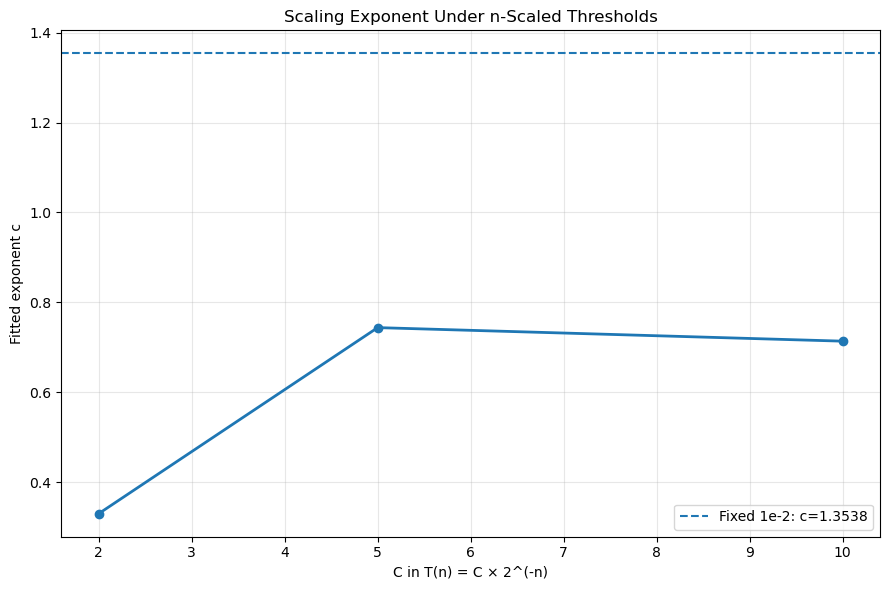

In [11]:
# ============================================================
# CELL 11 — EXPONENT VS C
# ============================================================

valid = scaled_fit_df.dropna(
    subset=["c"]
).copy()

plt.figure(figsize=(9, 6))

plt.plot(
    valid["C"],
    valid["c"],
    marker="o",
    linewidth=2
)

plt.axhline(
    baseline_fit["c"],
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Fixed 1e-2: c={baseline_fit['c']:.4f}"
    )
)

plt.xlabel("C in T(n) = C × 2^(-n)")
plt.ylabel("Fitted exponent c")
plt.title(
    "Scaling Exponent Under n-Scaled Thresholds"
)

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "c_vs_C.png"
    ),
    dpi=250,
    bbox_inches="tight"
)

plt.show()


### Cell 12 — Plot censoring versus \(C\)


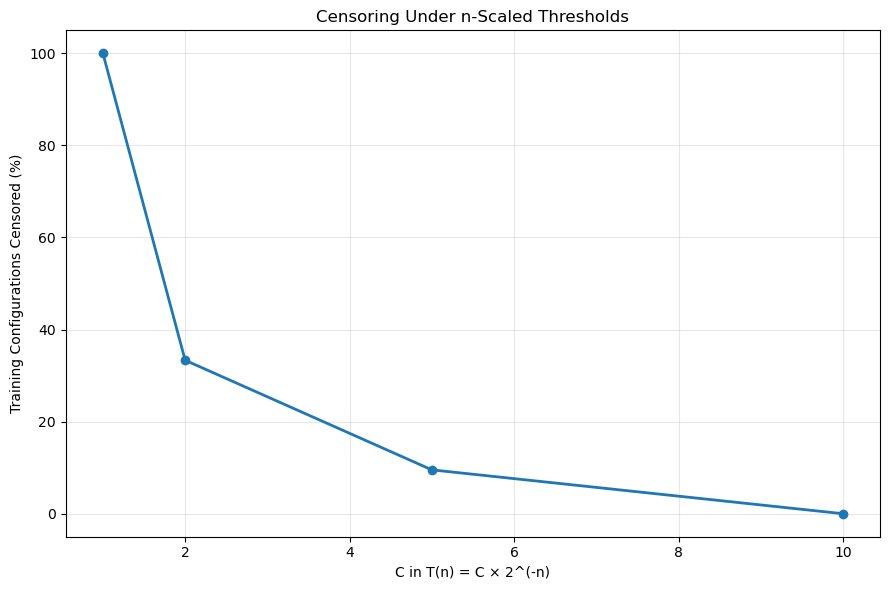

In [12]:
# ============================================================
# CELL 12 — CENSORING VS C
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    coverage_df["C"],
    coverage_df["censoring_percent"],
    marker="o",
    linewidth=2
)

plt.xlabel(
    "C in T(n) = C × 2^(-n)"
)

plt.ylabel(
    "Training Configurations Censored (%)"
)

plt.title(
    "Censoring Under n-Scaled Thresholds"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "censoring_vs_C.png"
    ),
    dpi=250,
    bbox_inches="tight"
)

plt.show()


### Cell 13 — Compare extracted \(\tau\) values


In [13]:
# ============================================================
# CELL 13 — TAU COMPARISON
# ============================================================

# Compare each n-scaled convention to the fixed threshold.

baseline_all = baseline_tau_df[
    ["n", "k", "tau_BP"]
].rename(
    columns={
        "tau_BP": "tau_fixed"
    }
)

tau_scaled_comparison = scaled_tau_df.merge(
    baseline_all,
    on=["n", "k"],
    how="left"
)

tau_scaled_comparison[
    "delta_tau"
] = (
    tau_scaled_comparison["tau_BP"]
    - tau_scaled_comparison["tau_fixed"]
)

tau_scaled_comparison[
    "abs_delta_tau"
] = (
    tau_scaled_comparison["delta_tau"]
    .abs()
)

tau_change_summary = (
    tau_scaled_comparison
    .groupby("C")
    .agg(
        mean_abs_delta_tau=(
            "abs_delta_tau",
            "mean"
        ),
        median_abs_delta_tau=(
            "abs_delta_tau",
            "median"
        ),
        max_abs_delta_tau=(
            "abs_delta_tau",
            "max"
        ),
        mean_signed_delta_tau=(
            "delta_tau",
            "mean"
        ),
        censored=(
            "censored",
            "sum"
        ),
    )
    .reset_index()
)

print("=" * 80)
print("TAU DIFFERENCE FROM FIXED 1e-2")
print("=" * 80)

display(
    tau_change_summary
)


TAU DIFFERENCE FROM FIXED 1e-2


,C,mean_abs_delta_tau,median_abs_delta_tau,max_abs_delta_tau,mean_signed_delta_tau,censored
0,1.0,24.600,27.0,30,24.600,40
1,2.0,17.600,18.0,29,17.600,20
2,5.0,13.200,10.5,29,11.600,13
3,10.0,10.825,9.5,29,8.325,8


### Cell 14 — Report whether the \(n\)-dependence is sensitive to threshold normalization


In [14]:
# ============================================================
# CELL 14 — DIAGNOSTIC INTERPRETATION
# ============================================================

print("\n" + "=" * 90)
print("CHECKPOINT 5 — DIAGNOSTIC SUMMARY")
print("=" * 90)

print(
    f"\nFixed-threshold baseline:"
)

print(
    f"  T = {BASELINE_THRESHOLD}"
)

print(
    f"  A = {baseline_fit['A']:.8f}"
)

print(
    f"  c = {baseline_fit['c']:.8f}"
)

print(
    "\nScaled-threshold fits:"
)

display(
    scaled_fit_df[
        [
            "C",
            "A",
            "c",
            "MAE",
            "RMSE",
            "R2_tau",
            "n_used",
            "n_censored",
        ]
    ]
)

print(
    "\nInterpretation rule:"
)

print(
    "If the exponent remains broadly similar across viable C values, "
    "that supports the possibility that the observed n-dependence is "
    "not solely caused by the absolute threshold."
)

print(
    "If c changes substantially or most configurations become censored, "
    "the n-scaled diagnostic indicates that threshold normalization "
    "materially affects the extracted onset law."
)

print(
    "\nThis notebook does NOT decide which threshold definition is "
    "physically 'correct'. It tests sensitivity to the normalization."
)



CHECKPOINT 5 — DIAGNOSTIC SUMMARY

Fixed-threshold baseline:
  T = 0.01
  A = 1166.08460326
  c = 1.35380173

Scaled-threshold fits:


,C,A,c,MAE,RMSE,R2_tau,n_used,n_censored
0,1.0,NaN,NaN,NaN,NaN,NaN,0,21
1,2.0,54.049009,0.330326,5.609192,6.867174,0.111679,14,7
2,5.0,151.135708,0.744037,7.012670,8.779316,-0.008064,19,2
3,10.0,95.373783,0.713920,6.460600,8.658278,-0.009648,21,0



Interpretation rule:
If the exponent remains broadly similar across viable C values, that supports the possibility that the observed n-dependence is not solely caused by the absolute threshold.
If c changes substantially or most configurations become censored, the n-scaled diagnostic indicates that threshold normalization materially affects the extracted onset law.

This notebook does NOT decide which threshold definition is physically 'correct'. It tests sensitivity to the normalization.


### Cell 15 — Save outputs


In [15]:
# ============================================================
# CELL 15 — SAVE CHECKPOINT 5 RESULTS
# ============================================================

scaled_threshold_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "scaled_threshold_values.csv"
    ),
    index=False
)

scaled_tau_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "n_scaled_tau_all_configs.csv"
    ),
    index=False
)

coverage_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "n_scaled_training_coverage.csv"
    ),
    index=False
)

scaled_fit_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "n_scaled_product_fits.csv"
    ),
    index=False
)

threshold_comparison_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "fixed_vs_n_scaled_comparison.csv"
    ),
    index=False
)

threshold_scale_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "threshold_scale_comparison.csv"
    ),
    index=False
)

tau_scaled_comparison.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "n_scaled_tau_comparison.csv"
    ),
    index=False
)

tau_change_summary.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "n_scaled_tau_change_summary.csv"
    ),
    index=False
)

checkpoint5_summary = {
    "checkpoint": 5,
    "input_file": INPUT_FILE,
    "fixed_threshold": BASELINE_THRESHOLD,
    "C_values": C_VALUES,
    "training_n": TRAIN_N,
    "held_out_n": HELD_OUT_N,
    "baseline_A": baseline_fit["A"],
    "baseline_c": baseline_fit["c"],
}

with open(
    os.path.join(
        OUTPUT_DIR,
        "checkpoint5_summary.json"
    ),
    "w"
) as f:
    json.dump(
        checkpoint5_summary,
        f,
        indent=2
    )

print("=" * 80)
print("CHECKPOINT 5 FILES SAVED")
print("=" * 80)

for fname in sorted(
    os.listdir(OUTPUT_DIR)
):
    print(
        os.path.join(
            OUTPUT_DIR,
            fname
        )
    )

print("\nSTATUS: COMPLETE")


CHECKPOINT 5 FILES SAVED
notebook5_n_scaled_threshold\c_vs_C.png
notebook5_n_scaled_threshold\censoring_vs_C.png
notebook5_n_scaled_threshold\checkpoint5_summary.json
notebook5_n_scaled_threshold\fixed_vs_n_scaled_comparison.csv
notebook5_n_scaled_threshold\n_scaled_product_fits.csv
notebook5_n_scaled_threshold\n_scaled_tau_all_configs.csv
notebook5_n_scaled_threshold\n_scaled_tau_change_summary.csv
notebook5_n_scaled_threshold\n_scaled_tau_comparison.csv
notebook5_n_scaled_threshold\n_scaled_training_coverage.csv
notebook5_n_scaled_threshold\scaled_threshold_values.csv
notebook5_n_scaled_threshold\threshold_scale_comparison.csv

STATUS: COMPLETE


One thing to pay particular attention to

Checkpoint 4 already tells us that threshold choice is not innocuous. Therefore Notebook 5 is not trying to “make the formula survive” by changing the threshold. It is specifically testing whether the \(n\)-dependence itself survives a physically motivated normalization.